In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [5]:
data = pd.read_csv('Position_Salaries.csv')

In [6]:
data

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [7]:
x = data.iloc[:,1].values  #  indep

In [8]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [9]:
y = data.iloc[:,2].values  

In [10]:
y    # dep

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lin_reg = LinearRegression()

In [13]:
lin_reg.fit(x.reshape(-1,1),y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


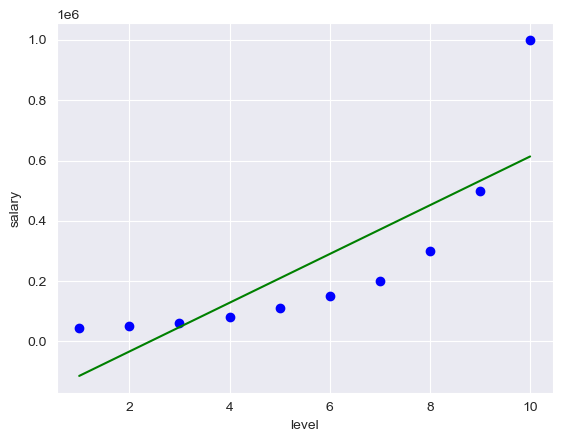

In [14]:
plt.scatter(x,y,c='b')
plt.plot(x,lin_reg.predict(x.reshape(-1,1)),c='g')
plt.xlabel('level')
plt.ylabel('salary')
plt.show()

In [15]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [16]:
x.reshape(-1,1)

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [17]:
lin_reg.predict(np.array([6]).reshape(-1,1))

array([289939.39393939])

In [19]:
from sklearn.preprocessing import PolynomialFeatures

In [20]:
poly_reg = PolynomialFeatures(degree=5)   #hyperparamter = 1,2,3,4,5...n

In [21]:
X_poly = poly_reg.fit_transform(x.reshape(-1,1))

In [22]:
X_poly

array([[1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [1.0000e+00, 2.0000e+00, 4.0000e+00, 8.0000e+00, 1.6000e+01,
        3.2000e+01],
       [1.0000e+00, 3.0000e+00, 9.0000e+00, 2.7000e+01, 8.1000e+01,
        2.4300e+02],
       [1.0000e+00, 4.0000e+00, 1.6000e+01, 6.4000e+01, 2.5600e+02,
        1.0240e+03],
       [1.0000e+00, 5.0000e+00, 2.5000e+01, 1.2500e+02, 6.2500e+02,
        3.1250e+03],
       [1.0000e+00, 6.0000e+00, 3.6000e+01, 2.1600e+02, 1.2960e+03,
        7.7760e+03],
       [1.0000e+00, 7.0000e+00, 4.9000e+01, 3.4300e+02, 2.4010e+03,
        1.6807e+04],
       [1.0000e+00, 8.0000e+00, 6.4000e+01, 5.1200e+02, 4.0960e+03,
        3.2768e+04],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03,
        5.9049e+04],
       [1.0000e+00, 1.0000e+01, 1.0000e+02, 1.0000e+03, 1.0000e+04,
        1.0000e+05]])

In [23]:
lin_reg2 = LinearRegression()

In [24]:
lin_reg2.fit(X_poly,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


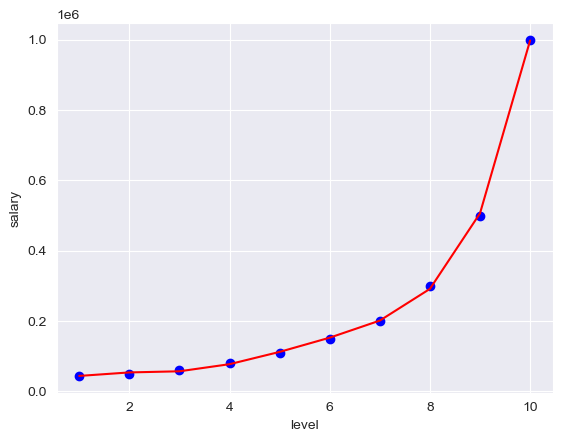

In [25]:
plt.scatter(x,y,c='b')
plt.plot(x,lin_reg2.predict(poly_reg.fit_transform(x.reshape(-1,1))),c='r')
plt.xlabel('level')
plt.ylabel('salary')
plt.show()

In [26]:
lin_reg2.predict(poly_reg.transform(np.array([6]).reshape(-1,1)))

array([152736.59673682])